(05-26-sdf-unificatie)=

# Cochrane: p = E[mx]

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1987–2013: van Hansen en Richard (1987) via Hansen en Jagannathan (1997)
en het handboek van Cochrane (2001, herziene druk 2005) tot Kan, Robotti en Shanken (2013).

**Wat we al weten.** Deel IV eindigde met een vak dat meer feiten had dan
theorieën. Het CAPM ([](#02-08-capm)) verklaart het gemiddelde niet, de
consumptie-SDF ([](#03-12-consumptie-capm)) haalt de Hansen-Jagannathan-grens
niet ([](#03-13-equity-premium-puzzle)), het driefactormodel
([](#04-18-fama-french)) past maar wacht op een verklaring, momentum
([](#04-19-momentum)) past in geen van alle, en [](#04-25-industrie) liet zien dat
beleggers inmiddels betalen voor precies die factoren. Elk model had zijn eigen
toets: GRS, Fama-MacBeth, GMM op de Euler-vergelijking.

**Welke vraag staat open.** Zijn deze modellen en toetsen verschillende theorieën,
of verschillende uitspraken over één en hetzelfde object — en zo ja, hoe vergelijk je ze?
```

## Overzicht

John Cochrane schreef in 2001 een handboek dat begint met één vergelijking,
$p = \E[mx]$, en in de inleiding de claim maakt dat de rest van het vak een
toepassing ervan is {cite}`Cochrane2005`. Prijs is de verwachting van payoff
maal een *stochastic discount factor* (SDF, stochastische disconteringsfactor:
de willekeurige variabele waarmee je een toekomstige payoff verdisconteert). Dat
de vergelijking bestaat, wisten we al: de fundamentele stelling
([](#03-11-apt-no-arbitrage)) garandeert een positieve $m$ zodra er geen
arbitrage is, en Lucas en Breeden ([](#03-12-consumptie-capm)) gaven haar een
economische naam. Nieuw is de *organisatie*. Het CAPM, het consumption CAPM, het
ICAPM, de APT en het driefactormodel zijn in deze taal geen concurrerende
raamwerken meer maar vijf keuzes voor $m$. Een bèta-representatie, een
mean-variance-frontier en een SDF zijn drie manieren om hetzelfde op te schrijven,
een equivalentie die Hansen en Richard in 1987 in een Hilbertruimte bewezen
{cite}`HansenRichard1987`. En GRS, Fama-MacBeth en de Euler-GMM van Hansen en
Singleton zijn verschillende momentvoorwaarden voor dezelfde vraag.

Dat verandert de epistemische status van het vak, motief 3 in zijn scharnierpunt.
Tot hier luidde de vraag: *welk model is waar?* Na Cochrane luidt ze: *welke $m$
prijst deze activa, en hoe ver zit elke kandidaat ernaast?* Hansen en Jagannathan
maakten van dat laatste een maat, de afstand van een kandidaat-$m$ tot de
dichtstbijzijnde geldige SDF, bedoeld voor een wereld waarin "their implied
stochastic discount factors do not price all portfolios correctly"
{cite}`HansenJagannathan1997`. Kan, Robotti en Shanken leidden in 2013 de
steekproefverdeling af van de cross-sectionele $R^2$ onder misspecificatie, en
vonden "several examples of large $R^2$ differences that are not statistically
significant" {cite}`KanRobottiShanken2013`. Het vak toetst niet meer of een model
waar is; het meet hoe fout het is.

Na een handberekening met drie toestanden en twee activa bewijzen we vier stellingen: de
unieke SDF $x^*$ in de payoff-ruimte, $R^*$ op de frontier, lineaire factormodellen als
bèta-modellen, en de HJ-afstand. We simuleren het verschil tussen de *prijs van risico* $b$
en de *premie* $\lambda$, en schatten tot slot de SDF van het CAPM, FF3 en FF3 plus momentum
met GMM op 35 portefeuilles, met de consumptie-SDF van [](#03-13-equity-premium-puzzle)
als contrast.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Stel dat prijzen onderling consistent zijn: dezelfde uitkering kost hetzelfde, een dubbele
uitkering het dubbele. Dan is de prijs een *lineaire* functie van de uitkering, en een
lineaire functie is altijd een inproduct met een vaste vector. Die vector is een
discontofactor. Er is geen nutsfunctie en geen evenwicht voor nodig, alleen de wet van
één prijs.

Er zijn meestal veel van zulke vectoren: met meer toestanden dan activa kun je een
discontofactor aanpassen in richtingen die geen activum "ziet". Maar precies één is zelf
na te maken met de verhandelde activa, en die is de kleinste; elke andere is dezelfde plus
ruis. Haar rendement is een bijzonder punt op de frontier van Markowitz. Wie de frontier
kent, kent een discontofactor, en omgekeerd.

Dan de stap die het vak veranderde. "Verwachte rendementen zijn lineair in een paar
bèta's" is hetzelfde als "de discontofactor is lineair in een paar factoren". Het CAPM,
het consumption CAPM en Fama-French verschillen niet in structuur, alleen in welke
variabelen in $m$ mogen staan.

Twee gevolgen maken dit meer dan notatie. Modellen zijn te vergelijken met één meetlat:
hoe ver hun $m$ van een geldige discontofactor ligt. En een factor die met de
discontofactor samenhangt, heeft een premie, ook als hij niets toevoegt aan de factoren
die er al staan. Wie wil weten of een factor *nodig* is, vraagt dus niet naar zijn premie
$\lambda$ maar naar zijn eigen gewicht $b$ in $m$; daarom zegt een tabel met significante
premies weinig over hoeveel factoren de wereld heeft.

## Toy-voorbeeld: drie toestanden, twee activa

Er zijn drie toestanden met kansen $\pi = (\tfrac14, \tfrac12, \tfrac14)$. Er zijn twee
verhandelde activa. We laten de tijdsindex weg: prijzen gelden op $t$, payoffs op
$t+1$.

| Activum | payoff in 1 | payoff in 2 | payoff in 3 | prijs $p$ |
|---|---|---|---|---|
| obligatie | 1{,}00 | 1{,}00 | 1{,}00 | 0{,}95 |
| aandeel | 1{,}50 | 1{,}00 | 0{,}50 | 0{,}90 |

Drie onbekenden, twee prijzen: de markt is incompleet ([](#thm-apt-no-arbitrage-uniek)).

**De payoff-ruimte.** Alle portefeuilles samen maken de payoffs
$\underline{X} = \{c_1\mathbf{1} + c_2 x_a\}$, een vlak in $\mathbb{R}^3$. Het
inproduct is $\E[xy] = \sum_s \pi_s x_s y_s$. Met $x_a$ het aandeel geldt
$\E[\mathbf{1}\cdot\mathbf{1}] = 1$, $\E[x_a] = \tfrac14 \cdot 1{,}5 + \tfrac12 \cdot 1 + \tfrac14 \cdot 0{,}5 = 1$
en $\E[x_a^2] = \tfrac14 \cdot 2{,}25 + \tfrac12 \cdot 1 + \tfrac14 \cdot 0{,}25 = 1{,}125$.
De tweede-momentenmatrix en haar inverse zijn

$$
\mathbf{G} = \begin{pmatrix} 1 & 1 \\ 1 & 1{,}125 \end{pmatrix},
\qquad
\det\mathbf{G} = 0{,}125,
\qquad
\mathbf{G}^{-1} = \begin{pmatrix} 9 & -8 \\ -8 & 8 \end{pmatrix}.
$$

**De SDF in de payoff-ruimte.** Zoek $x^* = c_1\mathbf{1} + c_2 x_a$ met $\E[x^* x] = p(x)$
voor beide activa. Dat is $\mathbf{G}\mathbf{c} = \mathbf{p}$, dus
$\mathbf{c} = \mathbf{G}^{-1}\mathbf{p} = (9 \cdot 0{,}95 - 8 \cdot 0{,}90;\ -8 \cdot 0{,}95 + 8 \cdot 0{,}90) = (1{,}35;\ -0{,}40)$
en

$$
x^* = 1{,}35 - 0{,}40\,x_a = (0{,}75;\ 0{,}95;\ 1{,}15).
$$

Controle: $\E[x^*] = 0{,}1875 + 0{,}475 + 0{,}2875 = 0{,}95$, de prijs van de
obligatie, en $\E[x^* x_a] = 0{,}28125 + 0{,}475 + 0{,}14375 = 0{,}90$, de prijs van
het aandeel. De SDF is laag in toestand 1, waar het aandeel veel uitkeert, en hoog
in toestand 3. De risicovrije rente is $R^f = 1/\E[x^*] = 1{,}0526$.

**Alle andere SDF's.** Een vector $\varepsilon$ die orthogonaal is aan beide activa moet
$\E[\varepsilon] = 0$ en $\E[\varepsilon x_a] = 0$ halen. $\varepsilon = (1;\ -1;\ 1)$
doet dat: $\tfrac14 - \tfrac12 + \tfrac14 = 0$ en $\tfrac14 \cdot 1{,}5 - \tfrac12 + \tfrac14 \cdot 0{,}5 = 0$.
Elke SDF is dus

$$
m = x^* + k\,\varepsilon = (0{,}75 + k;\ 0{,}95 - k;\ 1{,}15 + k), \qquad k \in \mathbb{R},
$$

strikt positief voor $k \in (-0{,}75;\ 0{,}95)$. Omdat $\E[x^*\varepsilon] = 0$ en
$\E[\varepsilon] = 0$, is $\Var(m) = \Var(x^*) + k^2\Var(\varepsilon)$ met
$\Var(x^*) = \E[x^{*2}] - 0{,}95^2 = 0{,}9225 - 0{,}9025 = 0{,}02$ en
$\Var(\varepsilon) = 1$. De SDF in de payoff-ruimte heeft de kleinste variantie
van allemaal, en $\sigma(x^*)/\E[x^*] = 0{,}1414/0{,}95 = 0{,}1489$.

**Het rendement $R^*$.** De prijs van $x^*$ is $p(x^*) = \E[x^{*2}] = 0{,}9225$, dus

$$
R^* = \frac{x^*}{0{,}9225} = (0{,}8130;\ 1{,}0298;\ 1{,}2466), \qquad
\E[R^*] = \frac{0{,}95}{0{,}9225} = 1{,}0298 .
$$

$R^*$ verdient *minder* dan de risicovrije rente: het is het rendement dat uitkeert
als de SDF hoog is, een verzekering.

**De bèta-representatie met $R^*$.** Het aandeel heeft $\E[R_a] = 1/0{,}90 = 1{,}1111$ en
een excess rendement van $0{,}0585$. Omdat $x^*$ lineair is in $x_a$ met helling
$-0{,}40$, is $\Cov(x_a, x^*) = -0{,}40 \cdot \Var(x_a) = -0{,}40 \cdot 0{,}125 = -0{,}05$,
en

$$
\beta_{a,R^*} = \frac{\Cov(R_a, R^*)}{\Var(R^*)}
= \frac{-0{,}05}{0{,}02} \cdot \frac{0{,}9225}{0{,}90} = -2{,}5625,
\qquad
\beta_{a,R^*}\left(\E[R^*] - R^f\right) = -2{,}5625 \cdot (-0{,}022821) = 0{,}0585 .
$$

Precies het excess rendement van het aandeel. Ook de Sharpe-ratio van het aandeel
klopt met de Hansen-Jagannathan-grens: $0{,}0585/\sigma(R_a) = 0{,}0585/0{,}3928 = 0{,}1489 = \sigma(x^*)/\E[x^*]$.
Met één risicovol activum ligt dat activum op de frontier, en wordt de grens exact gehaald.

In [2]:
prob = np.array([0.25, 0.50, 0.25])
X = np.array([[1.0, 1.5],        # state 1: bond, stock
              [1.0, 1.0],        # state 2
              [1.0, 0.5]])       # state 3
p = np.array([0.95, 0.90])

G = X.T @ (prob[:, None] * X)                 # second-moment matrix E[x x']
c = np.linalg.solve(G, p)                     # x* = X c
x_star = X @ c
R_star = x_star / (prob @ x_star**2)          # p(x*) = E[x*^2]
R_f = 1 / (prob @ x_star)
eps = np.array([1.0, -1.0, 1.0])


def E(v):
    return prob @ v


def cov(a, b):
    return E((a - E(a)) * (b - E(b)))


R_a = X[:, 1] / p[1]
beta_a = cov(R_a, R_star) / cov(R_star, R_star)
checks = {
    "E[x* x] = p (obligatie, aandeel)": X.T @ (prob * x_star),
    "E[eps x] = 0": X.T @ (prob * eps),
    "Var(x*)": cov(x_star, x_star),
    "sigma(x*)/E[x*]": np.sqrt(cov(x_star, x_star)) / E(x_star),
    "Sharpe aandeel": (E(R_a) - R_f) / np.sqrt(cov(R_a, R_a)),
    "beta_{a,R*}": beta_a,
    "beta x (E[R*] - R^f)": beta_a * (E(R_star) - R_f),
    "E[R_a] - R^f": E(R_a) - R_f,
}
assert np.allclose(c, [1.35, -0.40]) and np.allclose(x_star, [0.75, 0.95, 1.15])
assert np.allclose(checks["E[x* x] = p (obligatie, aandeel)"], p) and np.allclose(checks["E[eps x] = 0"], 0)
assert np.isclose(beta_a, -2.5625) and np.isclose(checks["beta x (E[R*] - R^f)"], E(R_a) - R_f)

print(f"G^-1 = {np.linalg.inv(G).round(4).tolist()},  c = {c.round(4)}")
print(f"x* = {x_star.round(4)},  R* = {R_star.round(4)},  E[R*] = {E(R_star):.4f},  R^f = {R_f:.4f}")
pd.Series({k: np.round(v, 4) for k, v in checks.items()})

G^-1 = [[9.0, -8.0], [-8.0, 8.0]],  c = [ 1.35 -0.4 ]
x* = [0.75 0.95 1.15],  R* = [0.813  1.0298 1.2466],  E[R*] = 1.0298,  R^f = 1.0526


E[x* x] = p (obligatie, aandeel)    [0.95, 0.9]
E[eps x] = 0                         [0.0, 0.0]
Var(x*)                                    0.02
sigma(x*)/E[x*]                          0.1489
Sharpe aandeel                           0.1489
beta_{a,R*}                             -2.5625
beta x (E[R*] - R^f)                     0.0585
E[R_a] - R^f                             0.0585
dtype: object

De code reproduceert $\mathbf{c}$, $x^*$, $R^*$ en de bèta van $-2{,}5625$ exact. Welke $k$
de markt "gebruikt", bepalen de prijzen niet, en een optie die alleen in toestand 3
uitkeert, heeft voor elke $k$ een andere prijs ([](#ex-sdf-unificatie-1)).

## Theorie

### Opzet: payoffs als Hilbertruimte

Eén periode, zonder tijdsindex, zoals in [](#03-11-apt-no-arbitrage); met $\E_t$ in
plaats van $\E$ geldt alles voorwaardelijk. Payoffs leven in $L^2$ met inproduct
$\E[xy]$ en norm $\|x\| = \sqrt{\E[x^2]}$, de taal van {cite:t}`HansenRichard1987` die
{cite:t}`Cochrane2005` overneemt. De *payoff-ruimte* $\underline{X} \subset L^2$ bevat alle
payoffs van portefeuilles van verhandelde activa; we nemen aan dat ze gesloten is en dat
de *wet van één prijs* geldt: de prijsfunctie $p$ op $\underline{X}$ is lineair. Dat is
zwakker dan geen arbitrage, want het zegt niets over positiviteit. Een *rendement* heeft
$p(R) = 1$, een *excess rendement* $p(R^e) = 0$.

### Stelling 1: er is precies één SDF in de payoff-ruimte

*Waarom zou dit waar zijn?* Een lineaire functie op een eindig-dimensionale ruimte
is een rij getallen, en een rij getallen is een inproduct met een vector. Dat de
vector in de ruimte zelf kan worden gekozen, is de Riesz-representatie. Uniciteit
volgt omdat twee kandidaten in de ruimte een verschil hebben dat orthogonaal is aan
de hele ruimte, en dus ook aan zichzelf.

:::{prf:theorem} Riesz-representatie van de prijsfunctie
:label: thm-sdf-unificatie-xstar

Laat $\underline{X}$ een gesloten deelruimte van $L^2$ zijn en $p$ een continue lineaire
prijsfunctie. Dan geldt:

1. Er bestaat precies één $x^* \in \underline{X}$ met $p(x) = \E[x^* x]$ voor alle $x \in \underline{X}$.
2. Een $m \in L^2$ is een SDF, $p(x) = \E[mx]$ voor alle $x \in \underline{X}$, dan en
   slechts dan als $m = x^* + \varepsilon$ met $\E[\varepsilon x] = 0$ voor alle $x \in \underline{X}$.
3. $x^*$ is de orthogonale projectie van elke SDF op $\underline{X}$, en $\E[m^2] \ge \E[x^{*2}]$.
   Als $\mathbf{1} \in \underline{X}$ geldt bovendien $\E[m] = \E[x^*]$ en $\sigma(m) \ge \sigma(x^*)$.

In het eindig-dimensionale geval met basis $\mathbf{x} = (x_1, \dots, x_N)'$,
prijzen $\mathbf{p}$ en $\mathbf{G} = \E[\mathbf{x}\mathbf{x}']$ inverteerbaar is

```{math}
:label: eq-sdf-unificatie-xstar
x^* = \mathbf{p}'\mathbf{G}^{-1}\mathbf{x} .
```
:::

:::{prf:proof}
*Bestaan.* In eindige dimensie: stel $x^* = \mathbf{c}'\mathbf{x}$ en eis
$\E[x^* x_i] = p_i$ voor elke basisvector; dat is $\mathbf{G}\mathbf{c} = \mathbf{p}$,
dus $\mathbf{c} = \mathbf{G}^{-1}\mathbf{p}$, wat [](#eq-sdf-unificatie-xstar) geeft.
Lineariteit van $p$ en van het inproduct brengt de gelijkheid van de basis over op
heel $\underline{X}$. In oneindige dimensie is dit de representatiestelling van
Riesz voor de Hilbertruimte $\underline{X}$.

*Uniciteit.* Als $x^*$ en $y^*$ in $\underline{X}$ allebei werken, is
$\E[(x^* - y^*)x] = 0$ voor alle $x \in \underline{X}$, in het bijzonder voor
$x = x^* - y^*$. Dan is $\E[(x^* - y^*)^2] = 0$.

*Karakterisering.* Als $m$ een SDF is, is $\varepsilon = m - x^*$ orthogonaal aan
$\underline{X}$ omdat $\E[mx] - \E[x^*x] = p(x) - p(x) = 0$; omgekeerd prijst
$x^* + \varepsilon$ met zo'n $\varepsilon$ alles correct. Omdat $x^* \in \underline{X}$ en
$\varepsilon \perp \underline{X}$, is $x^*$ de projectie van $m$ en geldt
$\E[m^2] = \E[x^{*2}] + \E[\varepsilon^2]$ (Pythagoras). Als $\mathbf{1} \in \underline{X}$,
is $\E[\varepsilon] = \E[\varepsilon \cdot \mathbf{1}] = 0$, dus hebben $m$ en $x^*$ hetzelfde
gemiddelde en tellen ook de varianties op. $\square$
:::

De fundamentele stelling ([](#thm-apt-no-arbitrage-fundamenteel)) zegt wanneer er een
*positieve* $m$ is; deze stelling zegt dat er altijd één kanonieke is, en dat de
keuzevrijheid van [](#thm-apt-no-arbitrage-uniek) precies $\underline{X}^{\perp}$ is. De
minimum-variantie-SDF $m^*_v$ van de Hansen-Jagannathan-frontier
([](#thm-equity-premium-puzzle-frontier)) is punt 3 toegepast op de ruimte opgespannen door
$\mathbf{1}$ en de rendementen. Positief hoeft $x^*$ niet te zijn.

### Stelling 2: $R^*$ ligt op de frontier

*Waarom zou dit waar zijn?* $x^*$ is het kortste element dat alles prijst, dus heeft $R^*$
van alle rendementen het kleinste tweede moment, en een rendement met minimaal tweede
moment bij zijn gemiddelde ligt op de frontier. Andere frontier-rendementen schuiven
daarvan af langs de ene richting die gemiddelden verandert. Definieer

```{math}
:label: eq-sdf-unificatie-rstar
R^* = \frac{x^*}{p(x^*)} = \frac{x^*}{\E[x^{*2}]},
\qquad
R^{e*} = \operatorname{proj}\left(\mathbf{1} \mid \underline{R}^{e}\right),
```

met $\underline{R}^e$ de ruimte van excess rendementen. Omdat $R^{e*}$ de projectie van de
constante is, geldt $\E[R^e] = \E[R^{e*}R^e]$ voor elk excess rendement.

:::{prf:theorem} Orthogonale decompositie van Hansen en Richard
:label: thm-sdf-unificatie-frontier

Neem aan dat $\E[R^{e*}] \neq 0$. Dan is elk rendement $R$ te schrijven als

```{math}
:label: eq-sdf-unificatie-decompositie
R = R^* + w\,R^{e*} + n,
\qquad
\E[n] = \E[nR^*] = \E[nR^{e*}] = 0,
```

met $w$ een scalair en $n$ een excess rendement. $R$ ligt op de mean-variance-frontier
dan en slechts dan als $n = 0$. In het bijzonder ligt $R^*$ op de frontier: het is
het rendement met het kleinste tweede moment.
:::

:::{prf:proof}
:class: dropdown

*Drie orthogonaliteiten.* (a) $R^*$ staat loodrecht op elk excess rendement:
$\E[R^* R^e] = \E[x^*R^e]/\E[x^{*2}] = p(R^e)/\E[x^{*2}] = 0$. In het bijzonder
$\E[R^*R^{e*}] = 0$. (b) Voor elk excess rendement $n \perp R^{e*}$ geldt
$\E[n] = \E[n \cdot \mathbf{1}] = \E[n\,R^{e*}] + \E[n(\mathbf{1} - R^{e*})] = 0 + 0$,
omdat $\mathbf{1} - R^{e*}$ loodrecht op de hele ruimte $\underline{R}^e$ staat.

*Constructie.* $R - R^*$ kost $1 - 1 = 0$, dus is een excess rendement. Kies
$w = (\E[R] - \E[R^*])/\E[R^{e*}]$ en $n = R - R^* - wR^{e*}$. Dan is $n$ een excess
rendement met $\E[n] = 0$. Uit de projectie-eigenschap is $\E[nR^{e*}] = \E[n] = 0$, en
uit (a) is $\E[nR^*] = 0$.

*Momenten.* Uit [](#eq-sdf-unificatie-decompositie) en de orthogonaliteiten:
$\E[R] = \E[R^*] + w\,\E[R^{e*}]$, en

$$
\E[R^2] = \E[R^{*2}] + w^2\,\E[R^{e*2}] + \E[n^2] .
$$

Rendementen met hetzelfde gemiddelde hebben dezelfde $w$, dus minimale variantie precies
als $n = 0$: de frontier. Met $w = 0$, $n = 0$ is dit $R^*$, het kleinste tweede moment. $\square$
:::

De frontier is de lijn $\{R^* + wR^{e*}\}$: de twee-fondsenstelling van
[](#01-04-markowitz), met als fondsen de SDF en de verwachting. De bèta-representatie
volgt zonder evenwicht.

:::{prf:corollary} SDF, frontier en bèta zijn equivalent
:label: cor-sdf-unificatie-beta

Met $\gamma = \E[R^{*2}]/\E[R^*]$ geldt voor elk rendement

```{math}
:label: eq-sdf-unificatie-beta-rstar
\E[R] = \gamma + \beta_{R,R^*}\left(\E[R^*] - \gamma\right),
\qquad
\beta_{R,R^*} = \frac{\Cov(R, R^*)}{\Var(R^*)} .
```

Als $\mathbf{1} \in \underline{X}$ is $\gamma = R^f$. Omgekeerd: als een rendement
$R^{mv}$ een bèta-representatie heeft voor alle activa, dan is $R^{mv}$ een
frontier-rendement en is $m = a + b R^{mv}$ een SDF voor geschikte $a, b$ (mits
$R^{mv}$ niet de minimum-variantieportefeuille is).
:::

:::{prf:proof}
Uit $x^* = R^*/\E[R^{*2}]$ en $p(R) = 1$ volgt $\E[R^*R] = \E[R^{*2}]$ voor elk
rendement. Schrijf het linkerlid als $\Cov(R, R^*) + \E[R^*]\E[R]$ en los op:
$\E[R] = \gamma - \Cov(R, R^*)/\E[R^*]$. Toegepast op $R = R^*$ geeft dit
$\E[R^*] - \gamma = -\Var(R^*)/\E[R^*]$; deel de eerste door de tweede. Met
$\mathbf{1} \in \underline{X}$ is $\E[x^*] = 1/R^f$, dus
$\gamma = \E[R^{*2}]/\E[R^*] = (1/\E[x^{*2}])/(\E[x^*]/\E[x^{*2}]) = R^f$. De omkering:
een bèta-representatie op $R^{mv}$ zegt dat $\E[R_i]$ affien is in
$\Cov(R_i, R^{mv})$; kies $a, b$ zodat $\E[(a + bR^{mv})R_i] = 1$ voor twee
rendementen met verschillende bèta, en lineariteit geeft het voor alle. $\square$
:::

[](#prop-capm-beta) en [](#thm-fama-french-sdf) waren speciale gevallen. Het CAPM zegt
niets anders dan: *de marktportefeuille is $R^* + wR^{e*}$ voor een zekere $w$*. In het
toy-voorbeeld is $\gamma = (1/0{,}9225)/1{,}0298 = 1{,}0526 = R^f$.

### Stelling 3: lineaire factormodellen zijn bèta-modellen

*Waarom zou dit waar zijn?* Een excess rendement kost niets, dus $\E[mR^e] = 0$, en dat
splitst in gemiddelde maal gemiddelde plus een covariantie. Is $m$ lineair in factoren, dan
is die covariantie een combinatie van covarianties met de factoren: op een schaal na
bèta's. De vertaalsleutel is de covariantiematrix van de factoren.

:::{prf:theorem} Van $m = a + \mathbf{b}'\mathbf{f}$ naar $\E[R^e] = \boldsymbol{\beta}'\boldsymbol{\lambda}$
:label: thm-sdf-unificatie-factor

Laat $\mathbf{f}$ een vector van $K$ factoren zijn met inverteerbare
$\boldsymbol{\Sigma}_f = \Var(\mathbf{f})$, en schrijf
$\boldsymbol{\beta}_i = \boldsymbol{\Sigma}_f^{-1}\Cov(\mathbf{f}, R^e_i)$ voor de
meervoudige regressiebèta's.

1. Als $m = a + \mathbf{b}'\mathbf{f}$ met $\E[m] \neq 0$ alle excess rendementen prijst,
   dan is

   ```{math}
   :label: eq-sdf-unificatie-lambda
   \E\!\left[R^e_i\right] = \boldsymbol{\beta}_i'\boldsymbol{\lambda},
   \qquad
   \boldsymbol{\lambda} = -\frac{\boldsymbol{\Sigma}_f\,\mathbf{b}}{\E[m]} .
   ```

2. Omgekeerd: als $\E[R^e_i] = \boldsymbol{\beta}_i'\boldsymbol{\lambda}$ voor alle $i$, dan
   prijst $m = 1 - \boldsymbol{\lambda}'\boldsymbol{\Sigma}_f^{-1}(\mathbf{f} - \E\mathbf{f})$
   alle excess rendementen, met $\E[m] = 1$.
:::

:::{prf:proof}
(1) $0 = \E[mR^e_i] = \E[m]\E[R^e_i] + \Cov(m, R^e_i) = \E[m]\E[R^e_i] + \mathbf{b}'\Cov(\mathbf{f}, R^e_i)$.
Met $\Cov(\mathbf{f}, R^e_i) = \boldsymbol{\Sigma}_f\boldsymbol{\beta}_i$ volgt
$\E[R^e_i] = -\mathbf{b}'\boldsymbol{\Sigma}_f\boldsymbol{\beta}_i/\E[m] = \boldsymbol{\beta}_i'\boldsymbol{\lambda}$.
(2) $\E[mR^e_i] = \E[R^e_i] - \boldsymbol{\lambda}'\boldsymbol{\Sigma}_f^{-1}\Cov(\mathbf{f}, R^e_i) = \E[R^e_i] - \boldsymbol{\lambda}'\boldsymbol{\beta}_i = 0$. $\square$
:::

Met excess rendementen alleen ligt de schaal van $m$ niet vast; pas een risicovrije rente
geeft $\E[m] = 1/R^f$. We normaliseren daarom $m = 1 - \mathbf{b}'(\mathbf{f} - \E\mathbf{f})$,
zoals in [](#thm-fama-french-sdf), en de sleutel wordt

```{math}
:label: eq-sdf-unificatie-sleutel
\boldsymbol{\lambda} = \boldsymbol{\Sigma}_f\,\mathbf{b},
\qquad
\mathbf{b} = \boldsymbol{\Sigma}_f^{-1}\boldsymbol{\lambda} .
```

Nu is de hele eerste helft van de reeks een tabel.

| Model | factoren in $m$ | wat de theorie over $\mathbf{b}$ zegt | lecture |
|---|---|---|---|
| CAPM | $R^e_m$ | $b = \E[R^e_m]/\sigma^2_m$; de markt is $R^* + wR^{e*}$ | [](#02-08-capm) |
| consumption CAPM | $\Delta c$ (lineair benaderd) | $b = \gamma$, $a$ uit $\beta$ en $R^f$ | [](#03-12-consumptie-capm) |
| ICAPM | $R^e_m$ en toestandsvariabelen $\mathbf{z}$ | gewichten uit hedgebehoeften; welke $\mathbf{z}$ zegt de theorie niet | [](#03-10-merton-icapm) |
| APT | $K$ dominante covariantierichtingen | $\mathbf{b}$ vrij; alleen $K$ klein | [](#03-11-apt-no-arbitrage) |
| FF3 | $R^e_m$, SMB, HML | $\mathbf{b} = \boldsymbol{\Sigma}_f^{-1}\E[\mathbf{f}]$ want verhandeld | [](#04-18-fama-french) |

De derde kolom wordt van boven naar beneden dunner: van een voorkeursparameter naar
alleen de eis dat een verhandelde factor zichzelf prijst. Motief 3 in één kolom.

### De prijs van risico $b$ tegenover de premie $\lambda$

*Waarom zou dit waar zijn?* $\lambda_j$ is de premie per eenheid bèta, en een factor
heeft een premie zodra hij met de SDF samenhangt, ook als die samenhang volledig
via een andere factor loopt. $b_j$ is het eigen gewicht van factor $j$ in de SDF,
gegeven alle andere. Zijn twee factoren sterk gecorreleerd en zit alleen de eerste
in $m$, dan heeft de tweede een grote $\lambda$ en een $b$ van nul.

:::{prf:proposition} Wat $b$ en $\lambda$ toetsen
:label: prop-sdf-unificatie-b-lambda

Met $m = 1 - \mathbf{b}'(\mathbf{f} - \E\mathbf{f})$ geldt

```{math}
:label: eq-sdf-unificatie-b-lambda
\lambda_j = -\Cov(f_j, m),
\qquad
b_j = 0 \iff m \text{ is een lineaire functie van } \mathbf{f}_{-j} \text{ alleen}.
```

Dus: $\lambda_j \neq 0$ zegt dat $f_j$ met de SDF correleert ("is $f_j$ beprijsd?");
$b_j \neq 0$ zegt dat $f_j$ nodig is om te prijzen, gegeven de andere factoren
("helpt $f_j$?"). Als de factoren ongecorreleerd zijn, vallen de twee vragen samen.
:::

:::{prf:proof}
$\Cov(f_j, m) = -\sum_k \Cov(f_j, f_k)\,b_k = -(\boldsymbol{\Sigma}_f\mathbf{b})_j = -\lambda_j$.
De tweede uitspraak is de definitie van $\mathbf{b}$ als coëfficiënt van $f_j$ in $m$.
Is $\boldsymbol{\Sigma}_f$ diagonaal, dan is $\lambda_j = \sigma_j^2 b_j$. $\square$
:::

Cochrane's praktische conclusie: wie wil weten of een factor moet worden toegevoegd,
toetst $b$, niet $\lambda$ {cite}`Cochrane2005`. Zijn numerieke voorbeeld met de
Fama-French-factoren hebben we niet kunnen verifiëren; de simulatie bouwt het na.

### GMM voor lineaire SDF-modellen

*Waarom zou dit waar zijn?* $\E[mR^e] = 0$ is een momentvoorwaarde zoals de
Euler-vergelijking van [](#03-12-consumptie-capm), maar *lineair* in $\mathbf{b}$: GMM
wordt een gewogen regressie van gemiddelde excess rendementen op hun *covarianties* met de
factoren, zonder intercept.

Met $T$ waarnemingen, $N$ testactiva en $\bar{\mathbf{f}}$ het steekproefgemiddelde
van de factoren zijn de momenten

```{math}
:label: eq-sdf-unificatie-momenten
\mathbf{g}_T(\mathbf{b}) = \frac1T\sum_t \mathbf{R}^e_t\left(1 - (\mathbf{f}_t - \bar{\mathbf{f}})'\mathbf{b}\right)
= \bar{\mathbf{R}}^e - \mathbf{C}\,\mathbf{b},
\qquad
\mathbf{C} = \widehat{\Cov}(\mathbf{R}^e, \mathbf{f}') \in \mathbb{R}^{N \times K}.
```

Minimaliseren van $\mathbf{g}_T'\mathbf{W}\mathbf{g}_T$ geeft

```{math}
:label: eq-sdf-unificatie-bhat
\hat{\mathbf{b}} = \left(\mathbf{C}'\mathbf{W}\mathbf{C}\right)^{-1}\mathbf{C}'\mathbf{W}\bar{\mathbf{R}}^e .
```

De *eerste stap* neemt $\mathbf{W} = \mathbf{I}$ (OLS van gemiddelden op covarianties), de
*tweede* $\mathbf{W} = \hat{\mathbf{S}}^{-1}$ uit [](#thm-consumptie-capm-gmm), met
$J_T = T\mathbf{g}_T'\hat{\mathbf{S}}^{-1}\mathbf{g}_T \to \chi^2(N-K)$. Omdat ook
$\bar{\mathbf{f}}$ geschat is, en de afgeleide van het moment naar $\E\mathbf{f}$ gelijk is
aan $\E[\mathbf{R}^e]\mathbf{b}'$, bouwen we $\hat{\mathbf{S}}$ uit

```{math}
:label: eq-sdf-unificatie-h
\mathbf{h}_t = \mathbf{R}^e_t\left(1 - (\mathbf{f}_t - \bar{\mathbf{f}})'\hat{\mathbf{b}}\right)
+ \bar{\mathbf{R}}^e\,(\mathbf{f}_t - \bar{\mathbf{f}})'\hat{\mathbf{b}},
```

en $\widehat{\Var}(\hat{\mathbf{b}}) = T^{-1}(\mathbf{C}'\mathbf{W}\mathbf{C})^{-1}\mathbf{C}'\mathbf{W}\hat{\mathbf{S}}\mathbf{W}\mathbf{C}(\mathbf{C}'\mathbf{W}\mathbf{C})^{-1}$.
De premies zijn $\hat{\boldsymbol{\lambda}} = \hat{\boldsymbol{\Sigma}}_f\hat{\mathbf{b}}$, met
$\hat{\boldsymbol{\Sigma}}_f$ als bekend behandeld: een tweede moment, en die zijn, motief 1,
goed gemeten. Of deze SDF-methode minder efficiënt is dan de bèta-methode, was omstreden
{cite}`KanZhou1999`; {cite:t}`JagannathanWang2002` concludeerden dat ze "is as efficient as
the beta method for estimating risk premiums".

### Stelling 4: de Hansen-Jagannathan-afstand

*Waarom zou dit waar zijn?* Met genoeg data verwerpt $J$ elk model; de bruikbare vraag is
*hoe* fout. De geldige SDF's vormen een affiene deelruimte ($x^*$ plus alles loodrecht op
de payoffs), dus heeft elke kandidaat een afstand ertoe, en die afstand is ook zijn
grootste prijsfout op een portefeuille van eenheidsnorm. Anders dan bij $J$ is de
weegmatrix voor alle modellen gelijk.

:::{prf:theorem} Hansen-Jagannathan-afstand
:label: thm-sdf-unificatie-hj

Laat $\underline{X}$ opgespannen worden door $\mathbf{x}$ met prijzen $\mathbf{p}$ en
$\mathbf{G} = \E[\mathbf{x}\mathbf{x}']$ inverteerbaar, en laat
$\mathcal{M} = \{m \in L^2 : \E[m\mathbf{x}] = \mathbf{p}\}$ de verzameling SDF's zijn.
Voor een kandidaat $y \in L^2$ met prijsfouten $\mathbf{g} = \E[y\mathbf{x}] - \mathbf{p}$ geldt

```{math}
:label: eq-sdf-unificatie-hj
\delta(y) \equiv \min_{m \in \mathcal{M}} \|y - m\|
= \max_{x \in \underline{X},\ \|x\| = 1} \left|\E[yx] - p(x)\right|
= \sqrt{\mathbf{g}'\mathbf{G}^{-1}\mathbf{g}} .
```

Voor een familie $y(\mathbf{b})$ is de HJ-afstand van het model $\min_{\mathbf{b}}\delta(y(\mathbf{b}))$:
GMM met $\mathbf{W} = \mathbf{G}^{-1}$.
:::

:::{prf:proof}
*Minimale afstand.* Door [](#thm-sdf-unificatie-xstar) is $\mathcal{M} = x^* + \underline{X}^{\perp}$.
Schrijf $y - x^* = u + v$ met $u \in \underline{X}$ en $v \perp \underline{X}$. Voor
$m = x^* + e$ met $e \perp \underline{X}$ is $\|y - m\|^2 = \|u\|^2 + \|v - e\|^2$,
minimaal bij $e = v$, met waarde $\|u\|$. Nu is $u = \mathbf{c}'\mathbf{x}$ met
$\mathbf{c} = \mathbf{G}^{-1}\E[\mathbf{x}(y - x^*)] = \mathbf{G}^{-1}\mathbf{g}$, dus
$\|u\|^2 = \mathbf{c}'\mathbf{G}\mathbf{c} = \mathbf{g}'\mathbf{G}^{-1}\mathbf{g}$.

*Grootste prijsfout.* Een payoff $x = \boldsymbol{\alpha}'\mathbf{x}$ heeft prijsfout
$\boldsymbol{\alpha}'\mathbf{g}$ en norm $\sqrt{\boldsymbol{\alpha}'\mathbf{G}\boldsymbol{\alpha}}$.
Cauchy-Schwarz in het $\mathbf{G}$-inproduct geeft
$|\boldsymbol{\alpha}'\mathbf{g}| = |(\mathbf{G}^{1/2}\boldsymbol{\alpha})'(\mathbf{G}^{-1/2}\mathbf{g})|
\le \sqrt{\boldsymbol{\alpha}'\mathbf{G}\boldsymbol{\alpha}}\sqrt{\mathbf{g}'\mathbf{G}^{-1}\mathbf{g}}$,
met gelijkheid voor $\boldsymbol{\alpha} \propto \mathbf{G}^{-1}\mathbf{g}$. $\square$
:::

Met excess rendementen is $\mathbf{p} = \mathbf{0}$ en $\mathbf{G} = \E[\mathbf{R}^e\mathbf{R}^{e\prime}]$.
Een afstand van $0{,}3$ in maanddata betekent: een portefeuille met $\sqrt{\E[x^2]} = 1$
wordt 30% per maand verkeerd geprijsd, bij 5% volatiliteit 1,5% per maand. Een model kan
$J$ verlagen door $\hat{\mathbf{S}}$ op te blazen, maar niet $\delta$: de maat "do[es] not
reward variability of discount factor proxies" {cite}`HansenJagannathan1997`.

In een steekproef is $\hat\delta$ ook voor het ware model niet nul. Onder correcte
specificatie is $\sqrt{T}\mathbf{g}_T(\hat{\mathbf{b}}) \to N(\mathbf{0}, \mathbf{P}\mathbf{S}\mathbf{P}')$
met $\mathbf{P} = \mathbf{I} - \mathbf{C}(\mathbf{C}'\mathbf{W}\mathbf{C})^{-1}\mathbf{C}'\mathbf{W}$,
dus is $T\hat\delta^2$ een gewogen som van $\chi^2(1)$-variabelen met als gewichten de
eigenwaarden van $\mathbf{G}^{-1/2}\mathbf{P}\mathbf{S}\mathbf{P}'\mathbf{G}^{-1/2}$; de
$p$-waarde simuleren we.

### Conditionering: het conditionele CAPM als factormodel

*Waarom zou dit waar zijn?* $p_t = \E_t[m_{t+1}x_{t+1}]$ geldt voorwaardelijk, dus mogen de
parameters van $m$ met de informatie op $t$ variëren. Een CAPM met
$m_{t+1} = a_t - b_t R^e_{m,t+1}$ en $a_t, b_t$ lineair in $z_t$ is onvoorwaardelijk een
model met factoren $R^e_m$, $z_t$ en $z_tR^e_{m,t+1}$.

Vermenigvuldig $0 = \E_t[m_{t+1}R^e_{t+1}]$ met een $z_t$ die op $t$ bekend is en neem
verwachtingen: $0 = \E[m_{t+1}(z_tR^e_{t+1})]$. Het excess rendement $z_tR^e_{t+1}$ is een
*managed portfolio* (een strategie die haar positie schaalt met een signaal); een
conditioneel model is een onvoorwaardelijk model op een grotere payoff-ruimte, de kern van
{cite:t}`HansenRichard1987`. {cite:t}`JagannathanWang1996` lieten zo bèta's en de
marktpremie variëren en namen menselijk kapitaal op in het vermogen; hun specificatie
"performs well in explaining the cross-section of average returns". In SDF-taal is dat
een uitbreiding van $m$ met geschaalde factoren ([](#ex-sdf-unificatie-2)).

## Simulatie: $b$ tegenover $\lambda$, en de HJ-afstand in eindige steekproeven

### (a) Een overbodige factor met een significante premie

In deze economie geeft FF3 de ware SDF. De factoren hebben maandgemiddelden
$(0{,}60;\ 0{,}20;\ 0{,}35)\%$, volatiliteiten $(4{,}5;\ 3;\ 3)\%$ en correlaties $0{,}3$
(markt-SMB) en $-0{,}2$ (markt-HML). 25 testactiva hebben marktbèta's rond één,
SMB-ladingen van $1{,}2$ tot $-0{,}2$, HML-ladingen van $-0{,}4$ tot $0{,}8$, en
$\E[R^e_i] = \boldsymbol{\beta}_i'\E[\mathbf{f}]$ exact. Ze laden bovendien met
$\gamma_i \sim N(0;\ 0{,}5^2)$ op een onbeprijsde schok $u$ (volatiliteit 3%), zoals een
bedrijfstakcontrast. De onderzoeker krijgt een vierde, verhandelde factor aangeboden:
$g = \mathrm{HML} + u$. Die is overbodig, $b_g = 0$, maar correleert $0{,}71$ met HML en
heeft dus $\lambda_g = \E[\mathrm{HML}] = 0{,}35\%$ per maand. We schatten het
vierfactormodel met tweestaps-GMM en met Fama-MacBeth zonder intercept, op 1000
steekproeven van vijftig jaar.

In [3]:
# TODO: naar hap.stats (GMM for linear SDF models, HJ distance, Fama-MacBeth without intercept)
CHI2_DRAWS = rng.chisquare(1, size=(4000, 50))     # shared draws for weighted chi-square p-values


def linear_sdf_gmm(Re, F, weight="efficient"):
    """GMM for m = 1 - b'(f - E f) on excess returns Re (T x N) and factors F (T x K).

    weight = "efficient": two-step GMM, J test.  weight = "hj": W = E[Re Re']^-1,
    Hansen-Jagannathan distance with a simulated p-value.  Standard errors account for
    the estimated factor means; lambda = Sigma_f b treats Sigma_f as known.
    """
    T, N = Re.shape
    Fc = F - F.mean(axis=0)
    ebar = Re.mean(axis=0)
    C = Re.T @ Fc / T                                      # Cov(R^e, f'), N x K

    def estimate(W):
        return np.linalg.solve(C.T @ W @ C, C.T @ W @ ebar)

    def spectral(b):
        h = Re * (1 - Fc @ b)[:, None] + np.outer(Fc @ b, ebar)
        return h.T @ h / T

    if weight == "hj":
        W = np.linalg.inv(Re.T @ Re / T)
    else:
        W = np.linalg.inv(spectral(estimate(np.eye(N))))
    b = estimate(W)
    S = spectral(b)
    V = np.linalg.inv(C.T @ W @ C)
    cov_b = V @ C.T @ W @ S @ W @ C @ V / T
    Sigma_f = Fc.T @ Fc / T
    g = ebar - C @ b
    out = {"b": b, "se_b": np.sqrt(np.diag(cov_b)), "lam": Sigma_f @ b,
           "se_lam": np.sqrt(np.diag(Sigma_f @ cov_b @ Sigma_f)), "g": g,
           "sd_m": np.sqrt(b @ Sigma_f @ b)}
    if weight == "hj":
        P = np.eye(N) - C @ V @ C.T @ W
        root = np.linalg.cholesky(W)
        weights = np.clip(np.linalg.eigvalsh(root.T @ P @ S @ P.T @ root), 0.0, None)
        out["hj"] = np.sqrt(g @ W @ g)
        out["p_hj"] = np.mean(CHI2_DRAWS[:, :N] @ weights >= T * g @ W @ g)
    else:
        out["J"] = T * g @ W @ g
        out["p_J"] = stats.chi2.sf(out["J"], N - F.shape[1])
    return out


def fama_macbeth_no_const(Re, F):
    """Full-sample multiple-regression betas, then monthly cross-sections without intercept."""
    T = len(Re)
    betas = np.linalg.lstsq(np.column_stack([np.ones(T), F]), Re, rcond=None)[0][1:].T
    lam_t = np.linalg.lstsq(betas, Re.T, rcond=None)[0].T
    return lam_t.mean(axis=0), lam_t.std(axis=0, ddof=1) / np.sqrt(T)

In [4]:
mu_f = np.array([0.006, 0.002, 0.0035])
sd_f = np.array([0.045, 0.030, 0.030])
Sigma_f_true = np.array([[1.0, 0.3, -0.2], [0.3, 1.0, 0.0], [-0.2, 0.0, 1.0]]) * np.outer(sd_f, sd_f)
chol_f = np.linalg.cholesky(Sigma_f_true)
B_true = np.column_stack([1 + 0.1 * rng.standard_normal(25),
                          np.repeat(np.linspace(1.2, -0.2, 5), 5),
                          np.tile(np.linspace(-0.4, 0.8, 5), 5)])
gamma_u = 0.5 * rng.standard_normal(25)
sd_u, sd_eps = 0.03, 0.015
mu_R = B_true @ mu_f
b_ff3 = np.linalg.solve(Sigma_f_true, mu_f)


def draw_economy(T, unpriced_shock=True):
    """T months of FF3 factors, the unpriced shock u, and 25 test assets priced by FF3."""
    f = mu_f + rng.standard_normal((T, 3)) @ chol_f.T
    u = sd_u * rng.standard_normal(T)
    R = mu_R + (f - mu_f) @ B_true.T + sd_eps * rng.standard_normal((T, 25))
    if unpriced_shock:
        R = R + np.outer(u, gamma_u)
    return R, f, u


rows_a = []
for _ in range(1000):
    R, f, u = draw_economy(600)
    F4 = np.column_stack([f, f[:, 2] + u])                # Mkt, SMB, HML, g = HML + u
    est = linear_sdf_gmm(R, F4)
    lam_fm, se_fm = fama_macbeth_no_const(R, F4)
    rows_a.append({"t(b_HML)": est["b"][2] / est["se_b"][2], "t(b_g)": est["b"][3] / est["se_b"][3],
                   "t(lambda_g) GMM": est["lam"][3] / est["se_lam"][3], "t(lambda_g) FM": lam_fm[3] / se_fm[3],
                   "b_g": est["b"][3], "lambda_g FM (%)": 100 * lam_fm[3], "p_J": est["p_J"]})
sim_a = pd.DataFrame(rows_a)

print(f"ware b (FF3) = {b_ff3.round(2)}, ware b_g = 0, ware lambda_g = {100 * mu_f[2]:.2f}% per maand")
print(f"J verwerpt het ware model (5%) in {(sim_a['p_J'] < 0.05).mean():.1%} van de steekproeven")
t_cols = sim_a.filter(like="t(")
pd.DataFrame({"mediaan t": t_cols.median(), "fractie |t| > 1.96": (t_cols.abs() > 1.96).mean()}).round(3)

ware b (FF3) = [3.49 0.65 4.94], ware b_g = 0, ware lambda_g = 0.35% per maand
J verwerpt het ware model (5%) in 4.4% van de steekproeven


,mediaan t,fractie |t| > 1.96
t(b_HML),2.423,0.689
t(b_g),0.010,0.058
t(lambda_g) GMM,1.949,0.494
t(lambda_g) FM,2.003,0.518


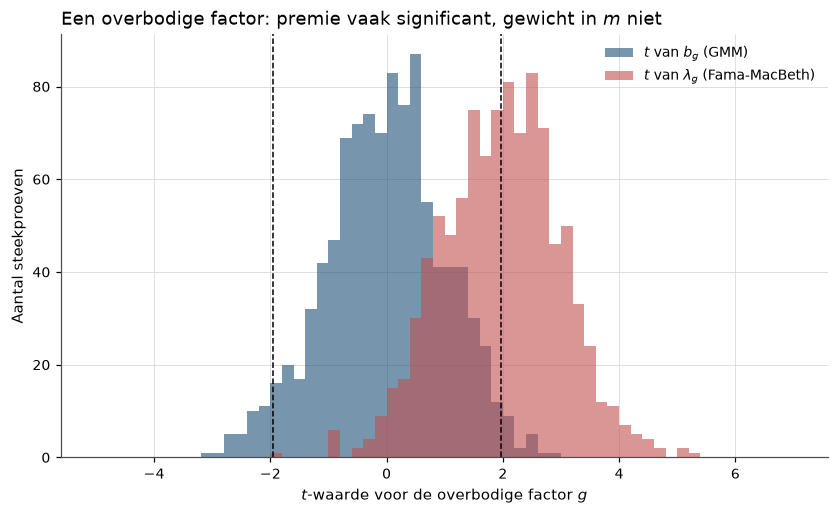

In [5]:
fig, ax = plt.subplots()
bins = np.linspace(-5, 7, 61)
ax.hist(sim_a["t(b_g)"], bins=bins, alpha=0.6, label="$t$ van $b_g$ (GMM)")
ax.hist(sim_a["t(lambda_g) FM"], bins=bins, alpha=0.6, label="$t$ van $\\lambda_g$ (Fama-MacBeth)")
for c in (-1.96, 1.96):
    ax.axvline(c, color="black", ls="--", lw=1)
ax.set_xlabel("$t$-waarde voor de overbodige factor $g$")
ax.set_ylabel("Aantal steekproeven")
ax.set_title("Een overbodige factor: premie vaak significant, gewicht in $m$ niet")
ax.legend()
plt.show()

:::{figure} #cel-sdf-unificatie-sim-b-lambda
:label: fig-sdf-unificatie-sim-b-lambda
:width: 90%

De factor $g$ voegt niets toe aan de ware SDF, maar correleert met HML. Zijn
gewicht $b_g$ is in ongeveer 5% van de steekproeven significant, zoals het hoort
onder de nulhypothese. Zijn premie $\lambda_g$ is dat in een groot deel van de
steekproeven, omdat hij terecht de premie van HML erft.
:::

Dit is Cochrane's punt in getallen. De toets op $b_g$ verwerpt in ongeveer 6% van de
steekproeven, de premie $\lambda_g$ is met GMM en Fama-MacBeth in ongeveer de helft
"significant", en $J$ verwerpt het ware model in ongeveer 5%. De premie is niet fout
geschat, $0{,}35\%$ is de ware waarde; ze beantwoordt een andere vraag. Dat ze niet altijd
significant is, is motief 1: bij 4,2% factorvolatiliteit is de standaardfout na vijftig
jaar ongeveer 0,17% per maand.

### (b) De HJ-afstand bij realistische $T$

Nu dezelfde economie zonder $u$. We schatten het ware model (FF3) en een fout model
(CAPM) en berekenen de HJ-afstand, op 1000 steekproeven van twintig en van vijftig
jaar. In de populatie is de afstand van FF3 nul; die van het CAPM volgt uit de ware
momenten.

In [6]:
Sigma_R = B_true @ Sigma_f_true @ B_true.T + sd_eps**2 * np.eye(25)
W_pop = np.linalg.inv(Sigma_R + np.outer(mu_R, mu_R))


def population_hj(columns):
    """Population HJ distance of the linear SDF in the selected true factors."""
    C = (B_true @ Sigma_f_true)[:, columns]
    b = np.linalg.solve(C.T @ W_pop @ C, C.T @ W_pop @ mu_R)
    g = mu_R - C @ b
    return np.sqrt(max(g @ W_pop @ g, 0.0))


rows_b = []
for T in (240, 600):
    for _ in range(1000):
        R, f, _ = draw_economy(T, unpriced_shock=False)
        ff3_fit, capm_fit = linear_sdf_gmm(R, f, "hj"), linear_sdf_gmm(R, f[:, :1], "hj")
        rows_b.append({"T": T, "HJ FF3": ff3_fit["hj"], "HJ CAPM": capm_fit["hj"],
                       "p FF3": ff3_fit["p_hj"], "p CAPM": capm_fit["p_hj"]})
sim_b = pd.DataFrame(rows_b)

print(f"populatie: HJ FF3 = {population_hj([0, 1, 2]):.3f}, HJ CAPM = {population_hj([0]):.3f}")
sim_b.assign(reject_ff3=sim_b["p FF3"] < 0.05, reject_capm=sim_b["p CAPM"] < 0.05).groupby("T").agg(**{
    "mediaan HJ FF3 (waar)": ("HJ FF3", "median"), "mediaan HJ CAPM (fout)": ("HJ CAPM", "median"),
    "verwerpt FF3 (5%)": ("reject_ff3", "mean"), "verwerpt CAPM (5%)": ("reject_capm", "mean"),
}).round(3)

populatie: HJ FF3 = 0.000, HJ CAPM = 0.142


,mediaan HJ FF3 (waar),mediaan HJ CAPM (fout),verwerpt FF3 (5%),verwerpt CAPM (5%)
T,,,,
240,0.309,0.345,0.055,0.160
600,0.194,0.242,0.054,0.438


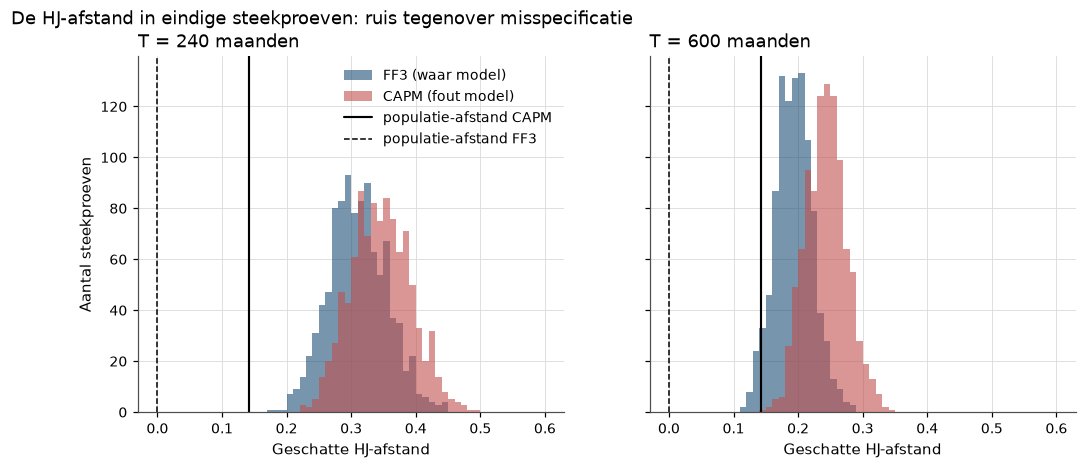

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
bins = np.linspace(0, 0.6, 61)
for ax, T in zip(axes, (240, 600)):
    part = sim_b[sim_b["T"] == T]
    ax.hist(part["HJ FF3"], bins=bins, alpha=0.6, label="FF3 (waar model)")
    ax.hist(part["HJ CAPM"], bins=bins, alpha=0.6, label="CAPM (fout model)")
    ax.axvline(population_hj([0]), color="black", lw=1.4, label="populatie-afstand CAPM")
    ax.axvline(0.0, color="black", ls="--", lw=1.0, label="populatie-afstand FF3")
    ax.set_title(f"T = {T} maanden")
    ax.set_xlabel("Geschatte HJ-afstand")
axes[0].set_ylabel("Aantal steekproeven")
axes[0].legend()
fig.suptitle("De HJ-afstand in eindige steekproeven: ruis tegenover misspecificatie", x=0.02, ha="left")
plt.show()

:::{figure} #cel-sdf-unificatie-sim-hj
:label: fig-sdf-unificatie-sim-hj
:width: 100%

De geschatte HJ-afstand van het ware model ligt ver van nul, en bij twintig jaar
data overlappen de verdelingen van het ware en het foute model grotendeels. Het
grootste deel van een geschatte afstand is steekproefruis, van de orde
$\sqrt{(N-K)/T}$; pas bij vijftig jaar schuift het foute model zichtbaar op.
:::

Dit is het 2%-motief in SDF-taal. De populatie-afstand van het CAPM is 0,14, maar het
*ware* model heeft na twintig jaar een mediane afstand rond 0,3: de ruisbodem
$\sqrt{(N-K)/T}$. Een fout van 0,14 is een alfa van 0,7% per maand bij 5% volatiliteit,
economisch enorm, en toch verwerpt de toets het CAPM na twintig jaar in een op de zes
steekproeven, na vijftig jaar in minder dan de helft; het ware model in ongeveer 5%. (Dat
de CAPM-afstand in élke steekproef boven die van FF3 ligt, is mechanisch: het CAPM is FF3
met twee gewichten op nul.) Een HJ-afstand hoort dus naast de ruisbodem, niet naast nul.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** John H. Cochrane, *Asset Pricing*, Princeton University Press 2005
{cite}`Cochrane2005` (GMM voor lineaire SDF-modellen, $b$ tegenover $\lambda$); Hansen en
Jagannathan, *Assessing Specification Errors in Stochastic Discount Factor Models*, Journal
of Finance 1997 {cite}`HansenJagannathan1997`; en Fama en French (2015)
{cite}`FamaFrench2015`, volgens wier samenvatting met winstgevendheid en investeringen
erbij "the value factor of the FF three-factor model becomes redundant for describing
average returns in the sample we examine".

**Wat.** (1) $\hat{\mathbf{b}}$, $J$ en de HJ-afstand voor CAPM, FF3 en FF3+UMD op 25
size/BM- en tien momentumportefeuilles. (2) De volatiliteit van de geschatte SDF naast de
Hansen-Jagannathan-grens en de consumptie-SDF van [](#03-13-equity-premium-puzzle). (3) De
redundantie van HML als $b$-uitspraak. Cochrane's eigen getallen konden we niet
verifiëren en noemen we niet.

**Data hier.** Kenneth French Data Library via `hap.data.french`: `"25_Portfolios_5x5"`,
`"10_Portfolios_Prior_12_2"` (beide waardegewogen), `"F-F_Research_Data_5_Factors_2x3"`
(markt, SMB, HML, RMW, CMA, RF) en `"F-F_Momentum_Factor"` (UMD), maandelijks,
1963-07 t/m 2026-07, in excess van de risicovrije rente.

**Verschil met het origineel.** Hansen en Jagannathan evalueerden andere modellen op
andere testactiva en hadden ook een maat met positieve $m$; wij niet. Fama en French
(2015) toetsten met GRS op andere sorteringen; wij kijken naar $b$ in GMM op 35
portefeuilles tot 2026. Alle factoren komen uit het vijffactorbestand (SMB wijkt licht af
van het driefactorbestand); $\hat{\mathbf{S}}$ zonder autocorrelatietermen.

**Verwachte afwijking.** (1) $J$ verwerpt het CAPM ($p < 0{,}01$). Onder FF3 is de
gemiddelde absolute prijsfout op de momentumportefeuilles minstens twee keer die op de 25;
UMD halveert haar ruwweg en krijgt een $b$ met $t > 2$. Met 757 maanden verwerpt $J$ alle
drie; de HJ-afstand daalt van CAPM via FF3 naar FF3+UMD en ligt boven de ruisbodem
$\sqrt{(N-K)/T} \approx 0{,}2$. (2) De jaarvolatiliteit van de FF3+UMD-SDF ligt boven 0,8,
boven de Sharpe-ratio van de markt en $\gamma\sigma_{\Delta c} \approx 0{,}36$ ($\gamma = 10$),
maar onder de in-sample HJ-grens van de 35 portefeuilles. (3) In FF5+UMD is
$b_{\mathrm{HML}}$ niet significant, $\lambda_{\mathrm{HML}}$ wel. Draait een teken om, of
verwerpt $J$ het CAPM niet, dan zit er een fout in de code.
```

In [8]:
ff5 = hap_data.french("F-F_Research_Data_5_Factors_2x3")
umd = hap_data.french("F-F_Momentum_Factor")["Mom"].rename("UMD")
rf = ff5["RF"]
size_bm = hap_data.french("25_Portfolios_5x5").sub(rf, axis=0)
momentum = hap_data.french("10_Portfolios_Prior_12_2").sub(rf, axis=0)
momentum.columns = [f"MOM {c}" for c in momentum.columns]

panel = (size_bm.join(momentum, how="inner")
         .join(ff5.drop(columns="RF"), how="inner").join(umd, how="inner")
         .loc["1963-07":"2026-07"])
assert panel.notna().all().all()
test_25, test_10 = list(size_bm.columns), list(momentum.columns)
test_35 = test_25 + test_10
models = {"CAPM": ["Mkt-RF"], "FF3": ["Mkt-RF", "SMB", "HML"], "FF3+UMD": ["Mkt-RF", "SMB", "HML", "UMD"]}
T_obs = len(panel)

mom_stats = hap.stats.summary_stats(panel[[test_10[0], test_10[-1]]])[["mean", "se_mean"]].astype(float) * 100
print(f"{panel.index[0]:%Y-%m} t/m {panel.index[-1]:%Y-%m}: T = {T_obs}, N = {len(test_35)}; "
      f"ruisbodem sqrt((N-K)/T) = {np.sqrt((35 - 1) / T_obs):.3f} (K = 1) tot {np.sqrt((35 - 4) / T_obs):.3f} (K = 4)")
mom_stats.rename(columns={"mean": "gem. excess (% p.m.)", "se_mean": "SE (% p.m.)"}).round(3)

1963-07 t/m 2026-07: T = 757, N = 35; ruisbodem sqrt((N-K)/T) = 0.212 (K = 1) tot 0.202 (K = 4)


,gem. excess (% p.m.),SE (% p.m.)
MOM Lo PRIOR,-0.031,0.306
MOM Hi PRIOR,1.162,0.228


De verliezers- en winnaarsdecielen verschillen ruim een procentpunt per maand in
gemiddeld rendement, met standaardfouten van een kwart tot een derde procentpunt: het
momentumverschil is een van de weinige gemiddelden in de cross-sectie die motief 1
overleeft.

### (1) SDF-schattingen, $J$-toets en HJ-afstand

In [9]:
fits, summary_rows = {}, {}
for tests_label, tests in {"25 size/BM": test_25, "25 size/BM + 10 momentum": test_35}.items():
    Re = panel[tests].to_numpy()
    for name, cols in models.items():
        F = panel[cols].to_numpy()
        eff, hj = linear_sdf_gmm(Re, F), linear_sdf_gmm(Re, F, "hj")
        fits[(tests_label, name)] = eff
        row = {"J": eff["J"], "df": len(tests) - len(cols), "p(J)": eff["p_J"],
               "HJ-afstand": hj["hj"], "p(HJ)": hj["p_hj"],
               "gem. |fout| 25 (% p.m.)": 100 * np.abs(hj["g"][:25]).mean()}
        if len(tests) == 35:
            row["gem. |fout| 10 mom. (% p.m.)"] = 100 * np.abs(hj["g"][25:]).mean()
        summary_rows[(tests_label, name)] = row
pd.DataFrame(summary_rows).T.round(3)

J    df  p(J)  HJ-afstand  p(HJ)  \
25 size/BM               CAPM      93.021  24.0  0.00       0.353  0.000   
                         FF3       82.667  22.0  0.00       0.333  0.000   
                         FF3+UMD   36.398  21.0  0.02       0.295  0.026   
25 size/BM + 10 momentum CAPM     128.566  34.0  0.00       0.410  0.000   
                         FF3      120.226  32.0  0.00       0.394  0.000   
                         FF3+UMD   99.381  31.0  0.00       0.361  0.000   

                                  gem. |fout| 25 (% p.m.)  \
25 size/BM               CAPM                       0.233   
                         FF3                        0.110   
                         FF3+UMD                    0.097   
25 size/BM + 10 momentum CAPM                       0.243   
                         FF3                        0.121   
                         FF3+UMD                    0.112   

                                  gem. |fout| 10 mom. (% p.m.)  
25 size/BM               CAPM                              NaN  
                         FF3                               NaN  
                         FF3+UMD                           NaN  
25 size/BM + 10 momentum CAPM                            0.242  
                         FF3                             0.264  
                         FF3+UMD                         0.124

In [10]:
b_rows = {}
for name, cols in models.items():
    est = fits[("25 size/BM + 10 momentum", name)]
    for j, col in enumerate(cols):
        b_rows[(name, col)] = {"b": est["b"][j], "t(b)": est["b"][j] / est["se_b"][j],
                               "lambda (% p.m.)": 100 * est["lam"][j], "t(lambda)": est["lam"][j] / est["se_lam"][j],
                               "gem. factor (% p.m.)": 100 * panel[col].mean()}
pd.DataFrame(b_rows).T.round(2)

b  t(b)  lambda (% p.m.)  t(lambda)  gem. factor (% p.m.)
CAPM    Mkt-RF  3.19  3.61             0.63       3.61                  0.60
FF3     Mkt-RF  3.32  3.51             0.56       3.16                  0.60
        SMB     0.56  0.44             0.18       1.58                  0.19
        HML     4.34  3.25             0.29       2.58                  0.30
FF3+UMD Mkt-RF  4.68  4.34             0.67       3.44                  0.60
        SMB     2.08  1.69             0.32       2.77                  0.19
        HML     6.40  4.26             0.31       2.67                  0.30
        UMD     5.24  4.59             0.61       3.27                  0.60

Het replicatieblok komt uit. FF3 brengt de gemiddelde prijsfout op de 25 size/BM-portefeuilles
terug tot ruim een tiende procentpunt per maand, maar laat op de momentumportefeuilles een
fout die ruim twee keer zo groot is, groter zelfs dan onder het CAPM: winnaars hebben een
negatieve HML-lading ([](#ex-fama-french-3)). UMD halveert die fout, met een $b$ van
$t = 4{,}6$. De HJ-afstanden dalen van 0,41 via 0,39 naar 0,36: dicht bij elkaar, ruim boven
de ruisbodem, en $J$ verwerpt alle drie. Dat $J$ ook FF3 op de 25 alleen verwerpt, is de
klein-groei-fout uit [](#04-18-fama-french). De premies $\lambda$ liggen meestal dicht bij
het gemiddelde van de factor, zoals [](#thm-fama-french-sdf) eist; uitzondering is SMB in
FF3+UMD (0,32% tegen 0,19% per maand).

### (2) De geschatte SDF en de Hansen-Jagannathan-grens

De geschatte SDF $\hat m_t = 1 - \hat{\mathbf{b}}'(\mathbf{f}_t - \bar{\mathbf{f}})$ is een
portefeuille van de factoren. Als de factoren verhandeld zijn en het model hun eigen
gemiddelden exact prijst, is $\hat{\mathbf{b}} = \boldsymbol{\Sigma}_f^{-1}\E[\mathbf{f}]$, de
tangentgewichten, en is $\sigma(\hat m)/\E[\hat m]$ de maximale Sharpe-ratio van de
factoren: de Hansen-Jagannathan-grens met gelijkheid ([](#eq-markowitz-tangent)). Omdat
GMM ook de testactiva moet prijzen, geldt dat hier bij benadering. We annualiseren
maandgetallen met $\sqrt{12}$.

In [11]:
mkt = panel["Mkt-RF"]
all_returns = panel[test_35 + models["FF3+UMD"]].to_numpy()
mean_all = all_returns.mean(axis=0)
sr_max_35 = np.sqrt(12 * mean_all @ np.linalg.solve(np.cov(all_returns, rowvar=False, bias=True), mean_all))

bound_rows = {}
for name, cols in models.items():
    F = panel[cols].to_numpy()
    mu = F.mean(axis=0)
    bound_rows[f"factor-SDF {name}"] = {
        "sigma(m)/E[m] per jaar": np.sqrt(12) * fits[("25 size/BM + 10 momentum", name)]["sd_m"],
        "max. Sharpe van de factoren per jaar": np.sqrt(12 * mu @ np.linalg.solve(np.cov(F, rowvar=False, bias=True).reshape(len(cols), len(cols)), mu)),
    }
bound_rows["Sharpe-ratio markt"] = {"sigma(m)/E[m] per jaar": np.nan,
                                    "max. Sharpe van de factoren per jaar": np.sqrt(12) * mkt.mean() / mkt.std(ddof=0)}
bound_rows["consumptie-SDF, gamma = 10, sigma(dc) = 3,6%"] = {"sigma(m)/E[m] per jaar": 10 * 0.036,
                                                              "max. Sharpe van de factoren per jaar": np.nan}
bound_rows["HJ-grens: 35 portefeuilles + 4 factoren (in-sample)"] = {"sigma(m)/E[m] per jaar": np.nan,
                                                                     "max. Sharpe van de factoren per jaar": sr_max_35}
b_umd = fits[("25 size/BM + 10 momentum", "FF3+UMD")]["b"]
F_umd = panel[models["FF3+UMD"]]
m_hat = 1 - (F_umd - F_umd.mean()) @ b_umd
print(f"maanden met m-dak < 0 (FF3+UMD): {(m_hat < 0).mean():.1%}; min = {m_hat.min():.2f} in {m_hat.idxmin():%Y-%m}, "
      f"max = {m_hat.max():.2f} in {m_hat.idxmax():%Y-%m}")
pd.DataFrame(bound_rows).T.round(3)

maanden met m-dak < 0 (FF3+UMD): 0.3%; min = -0.40 in 1976-01, max = 2.47 in 2001-01


,sigma(m)/E[m] per jaar,max. Sharpe van de factoren per jaar
factor-SDF CAPM,0.492,0.466
factor-SDF FF3,0.621,0.655
factor-SDF FF3+UMD,1.036,0.967
Sharpe-ratio markt,NaN,0.466
"consumptie-SDF, gamma = 10, sigma(dc) = 3,6%",0.360,NaN
HJ-grens: 35 portefeuilles + 4 factoren (in-sample),NaN,1.738


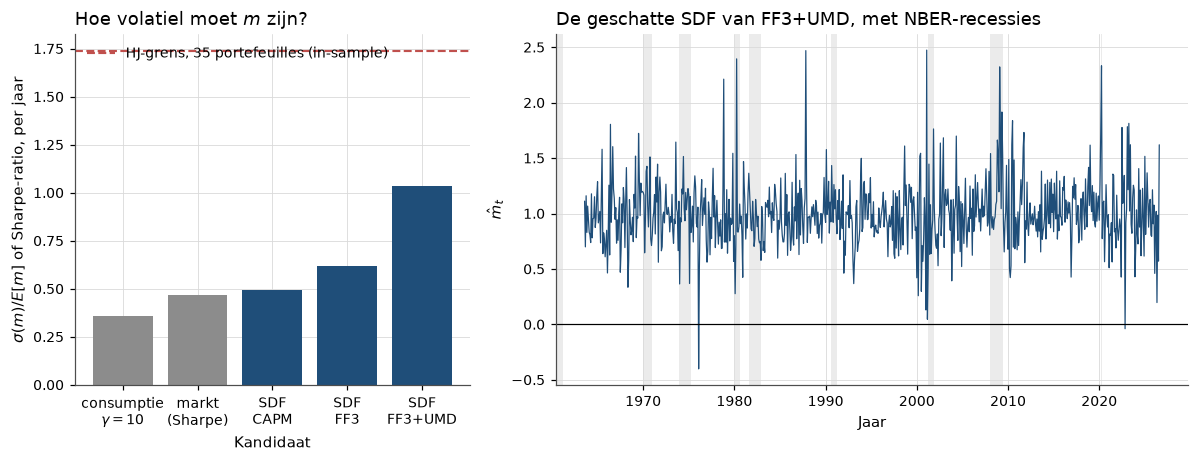

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), gridspec_kw={"width_ratios": [1, 1.6]})
labels = ["consumptie\n$\\gamma = 10$", "markt\n(Sharpe)", "SDF\nCAPM", "SDF\nFF3", "SDF\nFF3+UMD"]
values = [0.36, np.sqrt(12) * mkt.mean() / mkt.std(ddof=0)] + [
    np.sqrt(12) * fits[("25 size/BM + 10 momentum", n)]["sd_m"] for n in models]
axes[0].bar(labels, values, color=[hap.plotting.COLORS[7]] * 2 + [hap.plotting.COLORS[0]] * 3)
axes[0].axhline(sr_max_35, color=hap.plotting.COLORS[1], ls="--", lw=1.4, label="HJ-grens, 35 portefeuilles (in-sample)")
axes[0].set_ylabel("$\\sigma(m)/E[m]$ of Sharpe-ratio, per jaar")
axes[0].set_xlabel("Kandidaat")
axes[0].set_title("Hoe volatiel moet $m$ zijn?")
axes[0].legend(loc="upper left")

axes[1].plot(m_hat.index, m_hat, lw=0.8, color=hap.plotting.COLORS[0])
axes[1].axhline(0, color="black", lw=0.8)
hap.plotting.recession_shading(axes[1])
axes[1].set_xlabel("Jaar")
axes[1].set_ylabel("$\\hat m_t$")
axes[1].set_title("De geschatte SDF van FF3+UMD, met NBER-recessies")
fig.tight_layout()
plt.show()

:::{figure} #cel-sdf-unificatie-mhat
:label: fig-sdf-unificatie-mhat
:width: 100%

Links: de consumptie-SDF met $\gamma = 10$ haalt de Sharpe-ratio van de markt niet
([](#03-13-equity-premium-puzzle)); de factor-SDF's halen haar ruim, en die van FF3+UMD
schommelt ongeveer honderd procent per jaar. Ook zij blijven onder de in-sample grens van
de 35 portefeuilles, die door overfitting overschat is. Rechts: de geschatte SDF piekt in
maanden waarin de markt valt of momentum crasht, en is een enkele keer negatief.
:::

Dit is het contrast waarmee Deel V opent. De consumptie-SDF haalde de Sharpe-grens van de
markt pas bij $\gamma = 15$, met een rente van dertig procent
([](#03-13-equity-premium-puzzle)); een SDF uit vier factorportefeuilles haalt haar
moeiteloos. De prijs staat in het rechterpaneel: deze $m$ heeft geen economische inhoud.
Haar maximum valt in januari 2001, een momentumcrash, en in januari 1976 is ze negatief;
een negatieve SDF prijst de testactiva, maar geeft sommige opties op de factoren een
negatieve prijs ([](#rem-apt-no-arbitrage-sdf)).

### (3) $b$ tegenover $\lambda$: is HML overbodig?

In [13]:
Re35 = panel[test_35].to_numpy()
lambda_rows = {}
for name, cols in {"FF3+UMD": models["FF3+UMD"],
                   "FF5+UMD": ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "UMD"]}.items():
    F = panel[cols].to_numpy()
    est = linear_sdf_gmm(Re35, F)
    lam_fm, se_fm = fama_macbeth_no_const(Re35, F)
    for j, col in enumerate(cols):
        lambda_rows[(name, col)] = {"b": est["b"][j], "t(b)": est["b"][j] / est["se_b"][j],
                                    "lambda GMM (% p.m.)": 100 * est["lam"][j],
                                    "t(lambda) GMM": est["lam"][j] / est["se_lam"][j],
                                    "lambda FM (% p.m.)": 100 * lam_fm[j], "t(lambda) FM": lam_fm[j] / se_fm[j]}
    lambda_rows[(name, "J (p)")] = {"b": est["J"], "t(b)": est["p_J"]}
pd.DataFrame(lambda_rows).T.round(2)

b  t(b)  lambda GMM (% p.m.)  t(lambda) GMM  \
FF3+UMD Mkt-RF   4.68  4.34                 0.67           3.44   
        SMB      2.08  1.69                 0.32           2.77   
        HML      6.40  4.26                 0.31           2.67   
        UMD      5.24  4.59                 0.61           3.27   
        J (p)   99.38  0.00                  NaN            NaN   
FF5+UMD Mkt-RF   5.80  4.50                 0.61           3.05   
        SMB      3.57  2.24                 0.24           1.88   
        HML      2.46  0.68                 0.38           3.08   
        RMW      9.59  3.04                 0.35           2.26   
        CMA      8.72  1.29                 0.27           1.82   
        UMD      4.43  3.60                 0.54           2.74   
        J (p)   81.24  0.00                  NaN            NaN   

                lambda FM (% p.m.)  t(lambda) FM  
FF3+UMD Mkt-RF                0.60          3.69  
        SMB                   0.17          1.49  
        HML                   0.36          3.23  
        UMD                   0.61          3.79  
        J (p)                  NaN           NaN  
FF5+UMD Mkt-RF                0.56          3.45  
        SMB                   0.26          2.34  
        HML                   0.30          2.72  
        RMW                   0.40          2.56  
        CMA                   0.04          0.21  
        UMD                   0.60          3.74  
        J (p)                  NaN           NaN

In FF3+UMD hebben markt, HML en UMD een significante $b$ én $\lambda$; SMB heeft geen
significante $b$ en een premie die van de methode afhangt. Met RMW en CMA erbij gebeurt met
HML wat [](#prop-sdf-unificatie-b-lambda) voorspelt: $\lambda_{\mathrm{HML}}$ blijft met GMM
($t = 3{,}1$) en Fama-MacBeth ($t = 2{,}7$) significant, $b_{\mathrm{HML}}$ niet meer
($t = 0{,}7$). HML hangt samen met de SDF, maar voegt gegeven RMW en CMA weinig toe: de
redundantie van Fama en French in $b$-taal. Het gewicht verschuift naar RMW ($t = 3{,}0$) en,
onnauwkeurig, naar CMA; welke van de gecorreleerde HML en CMA "de" waardefactor is, beslist
deze steekproef niet. Wie alleen de Fama-MacBeth-kolom las, concludeerde het omgekeerde:
HML nodig, CMA met een premie van nul overbodig.

## Wat er brak, en wat daarna kwam

**Wat het raamwerk verklaart.** Alles wat in deze reeks tot hier gebeurde, in één taal.
CAPM, consumptie-SDF, APT en Fama-French zijn uitspraken over $m$; frontier, bèta en SDF
zijn dezelfde meetkunde; GRS, Fama-MacBeth en de Euler-GMM zijn momentvoorwaarden
$\E[mR^e] = 0$ met verschillende wegingen. Het leverde gereedschap dat blijft: de
HJ-grens als meetlat voor economische modellen, de HJ-afstand om foute modellen te
rangschikken, en $b$ tegenover $\lambda$ om te beslissen welke factor nodig is.

**Waar het breekt.** Het raamwerk zegt niet welke $m$. Op onze 35 portefeuilles
verwerpt $J$ zelfs FF3+UMD, en de HJ-afstanden van drie heel verschillende modellen
liggen dicht bij elkaar en ruim boven de ruisbodem die de simulatie liet zien. De
factor-SDF die de activa het best prijst, schommelt ongeveer honderd procent per jaar,
wordt soms negatief, en is een portefeuille zonder economische interpretatie; de
consumptie-SDF die wél een interpretatie heeft, haalt de grens niet. Precies daar zit
de barst: prijzen verklaren en prijzen *begrijpen* zijn in dit raamwerk twee
verschillende projecten geworden.

**Risico of vergissing?** De SDF-taal is neutraal, en dat is haar kracht en haar
beperking. De Chicago-lezing: $\hat m_t$ is hoog in recessies en crashes, dus markt, value
en momentum zijn beloningen voor het dragen van risico in slechte tijden, en de taak is
een economie te vinden waarin de marginale waarde van een euro zo sterk varieert. De
Yale-lezing: een SDF is niets meer dan een gewichtenvector die de gemeten gemiddelden
reproduceert. Als beleggers systematisch dezelfde vergissing maken over groei en
nieuws, bestaat er óók een lineaire $m$ die dat prijst, en die heeft precies dezelfde
covarianties met de factoren. Beide lezingen voorspellen dezelfde $J$-toets en dezelfde
HJ-afstand; wat ze zou scheiden, is een onafhankelijke meting van de marginale waarde van
geld, en die bestaat nauwelijks. Voor een belegger is het de vraag van Santa-Clara: wie de
tangentportefeuille van de factoren koopt, draagt die een risico dat beprijsd is, of
denkt die iets te weten wat de prijs niet wist?

**Wat er daarna kwam.** Drie onderzoeksprogramma's probeerden een economische $m$ te
bouwen die volatiel genoeg is om de Hansen-Jagannathan-grens te halen zonder de rente te
laten ontsporen: gewoontevorming, langetermijnrisico en rampen, in
[](#05-27-drie-antwoorden).

## Oefeningen

:::{exercise}
:label: ex-sdf-unificatie-1

**Welke SDF gebruikt de markt?** Neem het toy-voorbeeld en een put op het aandeel met
uitoefenprijs 1, payoff $(0;\ 0;\ 0{,}5)$.

1. Bereken de prijs van de put met $x^*$ en met $m = x^* + k\varepsilon$. Geef het interval
   van prijzen dat past bij strikt positieve SDF's.
2. Bereken $R^{e*}$ uit [](#eq-sdf-unificatie-rstar) en controleer
   $\E[R^e] = \E[R^{e*}R^e]$ voor het excess rendement van het aandeel.
3. Laat zien dat het rendement op de frontier met de hoogste Sharpe-ratio van de vorm
   $R^* + wR^{e*}$ is, en bereken $w$ voor het risicovrije rendement.
:::

:::{solution} ex-sdf-unificatie-1
:class: dropdown

**(1)** $\E[mx] = 0{,}125\,(1{,}15 + k)$: $0{,}14375$ bij $x^*$, en $(0{,}05;\ 0{,}2625)$ voor
$k \in (-0{,}75;\ 0{,}95)$. **(2)** $R^{e*} = (\E[R^e_a]/\E[R^{e2}_a])\,R^e_a$. **(3)** Het
risicovrije rendement ligt op de frontier, dus $R^f = R^* + wR^{e*}$ in elke toestand.

In [14]:
put = np.array([0.0, 0.0, 0.5])
k_bounds = np.array([-0.75, 0.95])
Re_a = R_a - R_f
Re_star = E(Re_a) / E(Re_a**2) * Re_a
w_rf = (R_f - E(R_star)) / E(Re_star)
put_bounds = [E((x_star + k * eps) * put) for k in k_bounds]
print(f"prijs put met x*: {E(x_star * put):.5f}; interval bij positieve m: ({put_bounds[0]:.4f}, {put_bounds[1]:.4f})")
print(f"E[R^e] = {E(Re_a):.5f}, E[R^e* R^e] = {E(Re_star * Re_a):.5f}")
print(f"w voor R^f = {w_rf:.4f}; R* + w R^e* = {(R_star + w_rf * Re_star).round(4)} (R^f = {R_f:.4f})")

prijs put met x*: 0.14375; interval bij positieve m: (0.0500, 0.2625)
E[R^e] = 0.05848, E[R^e* R^e] = 0.05848
w voor R^f = 1.0526; R* + w R^e* = [1.0526 1.0526 1.0526] (R^f = 1.0526)


Hier is $w = 1{,}0526$, numeriek gelijk aan $R^f$. Wat de oefening leert: de prijzen leggen
$x^*$ en de frontier vast, maar de prijs van alles buiten de payoff-ruimte hangt af van een
keuze van $m$ die de data niet maken. Een prijsmodel is precies zo'n keuze.
:::

:::{exercise}
:label: ex-sdf-unificatie-2

**Een conditioneel CAPM met geschaalde factoren.** Neem als signaal $z_t$ de log
dividend-prijsverhouding `dp` uit `hap.data.goyal_welch("monthly")`, een maand vertraagd
en gestandaardiseerd, en de 35 portefeuilles van de replicatie over 1963-07 t/m 2025-12.

1. Schrijf $m_{t+1} = a_t - b_t R^e_{m,t+1}$ met $a_t = a_0 + a_1 z_t$ en $b_t = b_0 + b_1 z_t$
   als onvoorwaardelijk lineair model.
2. Schat het met `linear_sdf_gmm`; vergelijk $J$, HJ-afstand en prijsfouten met CAPM en FF3.
3. Is $b_1$ significant?
:::

:::{solution} ex-sdf-unificatie-2
:class: dropdown

**(1)** $m_{t+1} = a_0 + a_1 z_t - b_0R^e_{m,t+1} - b_1 z_tR^e_{m,t+1}$: factoren $R^e_m$,
$z_t$ en $z_tR^e_{m,t+1}$.

In [15]:
dp = hap_data.goyal_welch("monthly")["dp"]
z = dp.shift(1).reindex(panel.index).loc[:"2025-12"]
z = (z - z.mean()) / z.std()
sub = panel.loc[z.index]
cond_factors = pd.DataFrame({"Mkt-RF": sub["Mkt-RF"], "z": z, "z x Mkt-RF": z * sub["Mkt-RF"]})
candidates = {"CAPM": sub[["Mkt-RF"]], "conditioneel CAPM": cond_factors, "FF3": sub[models["FF3"]]}
rows_ex2 = {}
for name, frame in candidates.items():
    eff, hj = linear_sdf_gmm(sub[test_35].to_numpy(), frame.to_numpy()), linear_sdf_gmm(sub[test_35].to_numpy(), frame.to_numpy(), "hj")
    rows_ex2[name] = {"J": eff["J"], "p(J)": eff["p_J"], "HJ": hj["hj"], "gem. |fout| (% p.m.)": 100 * np.abs(hj["g"]).mean(),
                      "t(b) laatste factor": eff["b"][-1] / eff["se_b"][-1]}
pd.DataFrame(rows_ex2).T.round(3)

,J,p(J),HJ,gem. |fout| (% p.m.),t(b) laatste factor
CAPM,126.530,0.000,0.409,0.234,3.554
conditioneel CAPM,55.399,0.006,0.388,0.228,2.298
FF3,118.226,0.000,0.394,0.159,3.171


Het geschaalde model verlaagt de gemiddelde prijsfout nauwelijks, haalt FF3 niet en wordt
door $J$ verworpen, al heeft $b_1$ een $t$-waarde boven twee. Leerzaam is het contrast:
$J$ halveert ruim, de HJ-afstand daalt een paar procent. Extra, ruisige factoren blazen
$\hat{\mathbf{S}}$ op en verlagen zo $J$, maar niet $\delta$. {cite:t}`JagannathanWang1996`
gebruikten een ander signaal en menselijk kapitaal; hun uitkomst volgt hier niet uit. Wat de oefening
leert: een "conditioneel model" is in de SDF-taal een onvoorwaardelijk model met meer
factoren, en moet dus met dezelfde meetlat worden beoordeeld als elk ander factormodel.
:::

:::{exercise}
:label: ex-sdf-unificatie-3

**De cross-sectionele $R^2$ en haar onzekerheid.** {cite:t}`KanRobottiShanken2013` waarschuwen
dat grote verschillen in cross-sectionele $R^2$ vaak niet significant zijn.

1. Bereken voor het CAPM, FF3 en FF3+UMD op de 35 portefeuilles de OLS-$R^2$ van gemiddelde
   excess rendementen op volle-steekproefbèta's, met intercept.
2. Trek 500 bootstrapsteekproeven van maanden (met teruglegging), herhaal (1) per steekproef,
   en rapporteer het 90%-interval van $R^2_{\mathrm{FF3+UMD}} - R^2_{\mathrm{FF3}}$ en van
   $R^2_{\mathrm{FF3}} - R^2_{\mathrm{CAPM}}$.
3. Vergelijk met de conclusie uit de HJ-afstanden.
:::

:::{solution} ex-sdf-unificatie-3
:class: dropdown

In [16]:
def cs_r2(Re, F):
    """Cross-sectional OLS R^2 of mean excess returns on full-sample betas, with intercept."""
    T = len(Re)
    betas = np.linalg.lstsq(np.column_stack([np.ones(T), F]), Re, rcond=None)[0][1:].T
    Z = np.column_stack([np.ones(Re.shape[1]), betas])
    means = Re.mean(axis=0)
    resid = means - Z @ np.linalg.lstsq(Z, means, rcond=None)[0]
    return 1 - resid.var() / means.var()


factor_arrays = {name: panel[cols].to_numpy() for name, cols in models.items()}
point = {name: cs_r2(Re35, F) for name, F in factor_arrays.items()}
boot = []
for _ in range(500):
    idx = rng.integers(0, T_obs, T_obs)
    boot.append({name: cs_r2(Re35[idx], F[idx]) for name, F in factor_arrays.items()})
boot = pd.DataFrame(boot)
diffs = {"FF3+UMD - FF3": boot["FF3+UMD"] - boot["FF3"], "FF3 - CAPM": boot["FF3"] - boot["CAPM"]}
print("R2:", {k: round(v, 3) for k, v in point.items()})
pd.DataFrame({k: v.quantile([0.05, 0.5, 0.95]) for k, v in diffs.items()}).T.round(3)

R2: {'CAPM': np.float64(0.11), 'FF3': np.float64(0.496), 'FF3+UMD': np.float64(0.758)}


,0.05,0.50,0.95
FF3+UMD - FF3,0.080,0.230,0.418
FF3 - CAPM,0.101,0.359,0.623


De bootstrap schat de bèta's per steekproef opnieuw: een ruwe versie van de
misspecificatie-robuuste inferentie van Kan, Robotti en Shanken. De $R^2$ stijgt van 0,11
via 0,50 naar 0,76. Beide verschillen zijn in meer dan 95% van de steekproeven positief,
maar breed: dat UMD 23 procentpunt toevoegt, is verenigbaar met acht en met ruim veertig.
En een hoge $R^2$ met vrij intercept kan samengaan met verkeerde premies
([](#prop-fama-french-mechanisch)). Wat de oefening leert: een rangorde van modellen is pas
een resultaat als ze de steekproefonzekerheid overleeft.
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->